In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.knn import KNN
from utils.metrics_evaluator import MetricsEvaluator
from utils.helpers import bulk_min_max_normalization, to_percent, missing_value_insight, plot_distribution, fill_missing_values

In [2]:
def drawHistogram(df: pd.DataFrame, col: str):
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribusi Data {col}')
    plt.show()

In [3]:
columns = {
    'age': 'umur', 
    'gender': 'jenis_kelamin', 
    'systolic_bp': 'sistolik', 
    'diastolic_bp': 'diastolik', 
    'glucose': 'glukosa', 
    'diabetic': 'diagnosa'
    }
df = pd.read_csv("new_dataset.csv").rename(columns=columns)
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [4]:
jumlah_diagnosa = df['diagnosa'].value_counts()

print(f"No  : {jumlah_diagnosa.get('No', 0)}")
print(f"Yes : {jumlah_diagnosa.get('Yes', 0)}")

No  : 344
Yes : 344


Fill Missing Values

In [5]:
missing_value_insight(pd.DataFrame(df['umur']))

,Missing Values,Percentage
umur,0,0.0


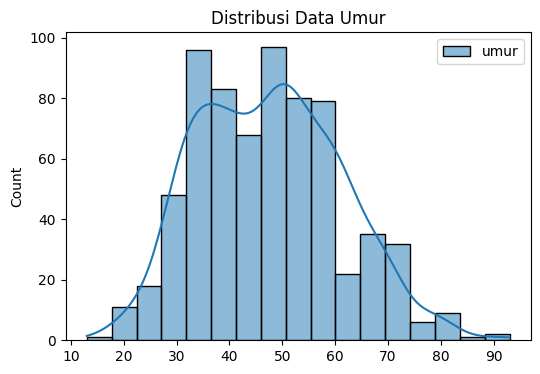

In [6]:
plot_distribution(pd.DataFrame(df['umur']))

In [7]:
df['umur'] = fill_missing_values(df['umur'], method='median')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [8]:
missing_value_insight(pd.DataFrame(df['jenis_kelamin']))

,Missing Values,Percentage
jenis_kelamin,0,0.0


In [9]:
uniqueGenderValuesCount = df['jenis_kelamin'].nunique()
uniqueGenderValues = np.array(df['jenis_kelamin'].unique())

print(f"Jumlah nilai unik pada kolom 'jenis_kelamin': {uniqueGenderValuesCount}")
print(f"Nilai unik pada kolom 'jenis_kelamin': {uniqueGenderValues}")

Jumlah nilai unik pada kolom 'jenis_kelamin': 2
Nilai unik pada kolom 'jenis_kelamin': ['Male' 'Female']


In [10]:
df['jenis_kelamin'] = fill_missing_values(df['jenis_kelamin'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [11]:
missing_value_insight(pd.DataFrame(df['pulse_rate']))

,Missing Values,Percentage
pulse_rate,0,0.0


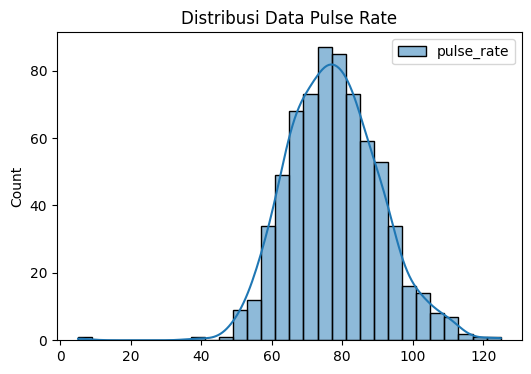

In [12]:
plot_distribution(pd.DataFrame(df['pulse_rate']))

In [13]:
df['pulse_rate'] = fill_missing_values(df['pulse_rate'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [14]:
missing_value_insight(pd.DataFrame(df['sistolik']))

,Missing Values,Percentage
sistolik,0,0.0


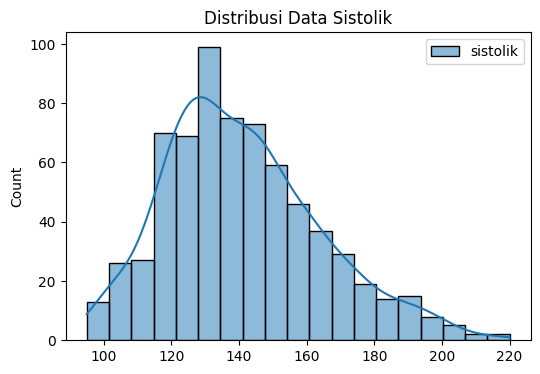

In [15]:
plot_distribution(pd.DataFrame(df['sistolik']))

In [16]:
df['sistolik'] = fill_missing_values(df['sistolik'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [17]:
missing_value_insight(pd.DataFrame(df['diastolik']))

,Missing Values,Percentage
diastolik,0,0.0


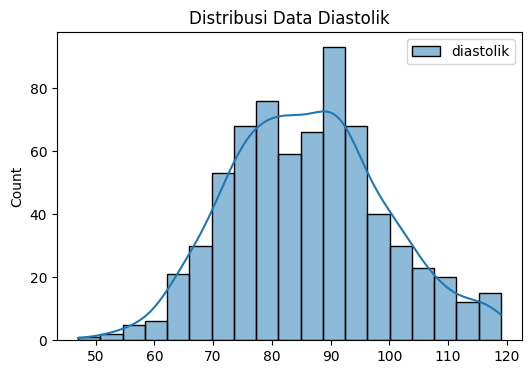

In [18]:
plot_distribution(pd.DataFrame(df['diastolik']))

In [19]:
df['diastolik'] = fill_missing_values(df['diastolik'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [20]:
missing_value_insight(pd.DataFrame(df['glukosa']))

,Missing Values,Percentage
glukosa,0,0.0


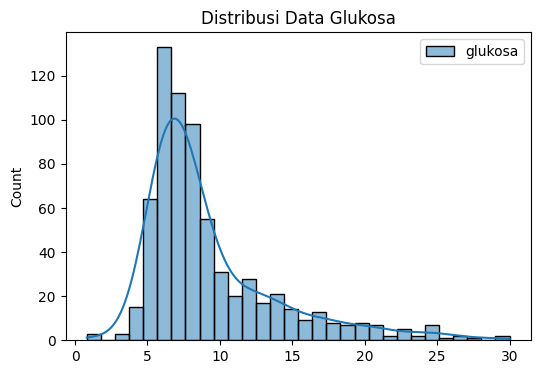

In [21]:
plot_distribution(pd.DataFrame(df['glukosa']))

In [22]:
df['glukosa'] = fill_missing_values(df['glukosa'], method='median')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [23]:
missing_value_insight(pd.DataFrame(df['height']))

,Missing Values,Percentage
height,0,0.0


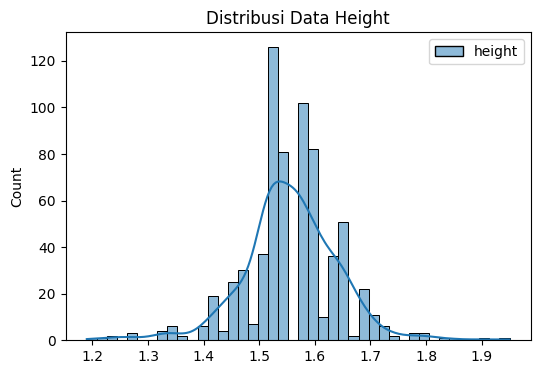

In [24]:
plot_distribution(pd.DataFrame(df['height']))

In [25]:
df['height'] = fill_missing_values(df['height'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [26]:
missing_value_insight(pd.DataFrame(df['weight']))

,Missing Values,Percentage
weight,0,0.0


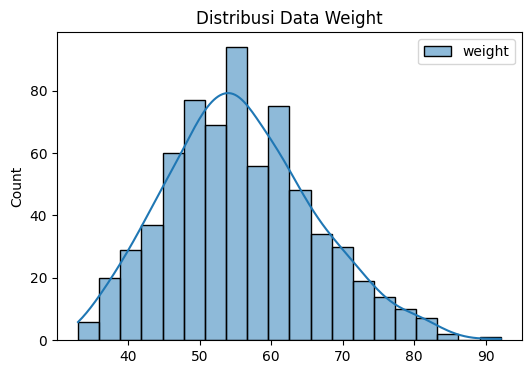

In [27]:
plot_distribution(pd.DataFrame(df['weight']))

In [28]:
df['weight'] = fill_missing_values(df['weight'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [29]:
missing_value_insight(pd.DataFrame(df['bmi']))

,Missing Values,Percentage
bmi,0,0.0


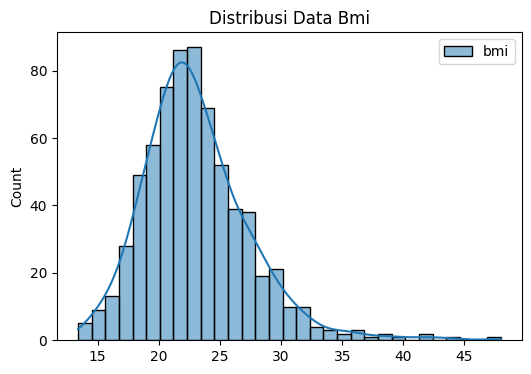

In [30]:
plot_distribution(pd.DataFrame(df['bmi']))

In [31]:
df['bmi'] = fill_missing_values(df['bmi'], method='mean')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [32]:
missing_value_insight(pd.DataFrame(df['family_diabetes']))

,Missing Values,Percentage
family_diabetes,0,0.0


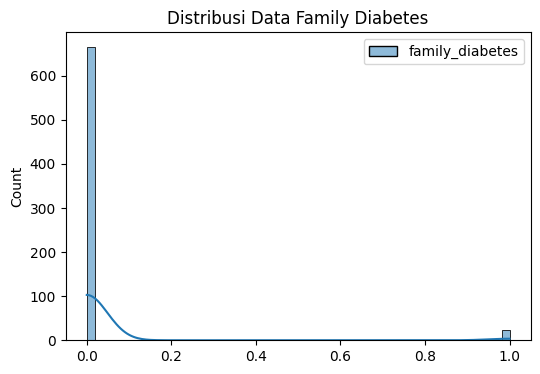

In [33]:
plot_distribution(pd.DataFrame(df['family_diabetes']))

In [34]:
df['family_diabetes'] = fill_missing_values(df['family_diabetes'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [35]:
missing_value_insight(pd.DataFrame(df['hypertensive']))

,Missing Values,Percentage
hypertensive,0,0.0


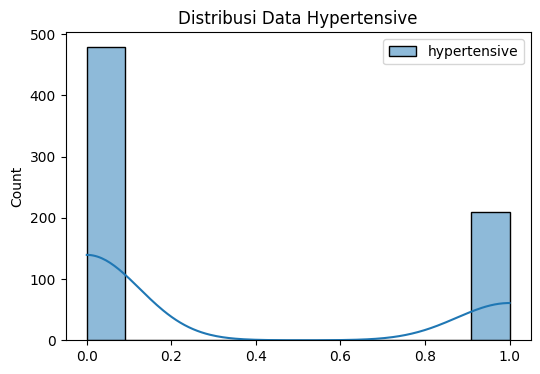

In [36]:
plot_distribution(pd.DataFrame(df['hypertensive']))

In [37]:
df['hypertensive'] = fill_missing_values(df['hypertensive'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [38]:
missing_value_insight(pd.DataFrame(df['family_hypertension']))

,Missing Values,Percentage
family_hypertension,0,0.0


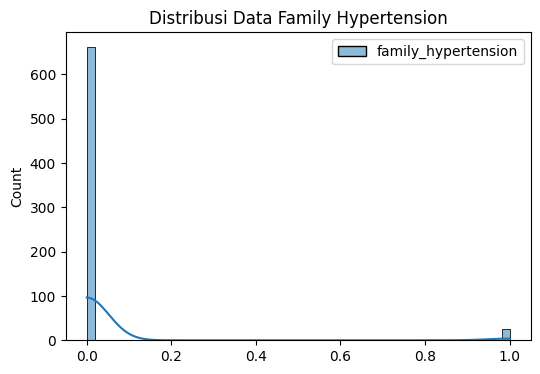

In [39]:
plot_distribution(pd.DataFrame(df['family_hypertension']))

In [40]:
df['family_hypertension'] = fill_missing_values(df['family_hypertension'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [41]:
missing_value_insight(pd.DataFrame(df['cardiovascular_disease']))

,Missing Values,Percentage
cardiovascular_disease,0,0.0


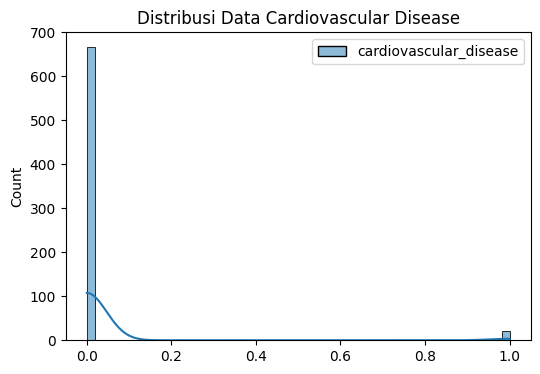

In [42]:
plot_distribution(pd.DataFrame(df['cardiovascular_disease']))

In [43]:
df['cardiovascular_disease'] = fill_missing_values(df['cardiovascular_disease'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [44]:
missing_value_insight(pd.DataFrame(df['stroke']))

,Missing Values,Percentage
stroke,0,0.0


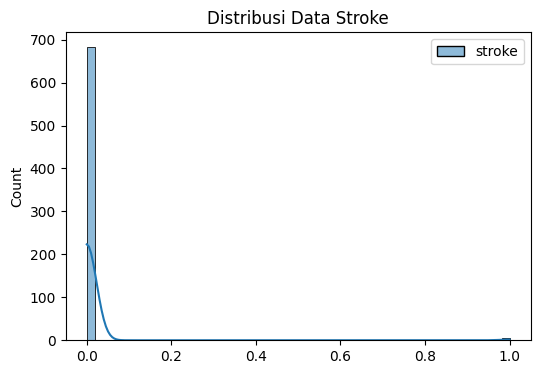

In [45]:
plot_distribution(pd.DataFrame(df['stroke']))

In [46]:
df['stroke'] = fill_missing_values(df['stroke'], method='mode')
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes


In [47]:
# Normalisasi kolom family_hypertension
df['norm_family_hypertension'] = bulk_min_max_normalization(df['family_hypertension'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No,0.0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No,0.0
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No,0.0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No,0.0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes,0.0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes,0.0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes,0.0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes,0.0


In [48]:
# Normalisasi kolom cardiovascular_disease
df['norm_cardiovascular_disease'] = bulk_min_max_normalization(df['cardiovascular_disease'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No,0.0,0.0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No,0.0,0.0
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No,0.0,0.0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No,0.0,0.0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes,0.0,0.0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes,0.0,0.0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes,0.0,0.0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes,0.0,0.0


In [49]:
# Normalisasi kolom stroke
df['norm_stroke'] = bulk_min_max_normalization(df['stroke'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No,0.0,0.0,0.0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No,0.0,0.0,0.0
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No,0.0,0.0,0.0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No,0.0,0.0,0.0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes,0.0,0.0,0.0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes,0.0,0.0,0.0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes,0.0,0.0,0.0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes,0.0,0.0,0.0


Data Transformation

In [50]:
# Mapping Gender: Female to 1, Male to 0
df['transformed_gender'] = df['jenis_kelamin'].map(lambda e: 1 if e == 'Female' else 0)
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,No,0.0,0.0,0.0,0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,No,0.0,0.0,0.0,1
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,No,0.0,0.0,0.0,0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,No,0.0,0.0,0.0,0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,No,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,Yes,0.0,0.0,0.0,0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,Yes,0.0,0.0,0.0,0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,Yes,0.0,0.0,0.0,0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,Yes,0.0,0.0,0.0,0


In [51]:
uniqueDiagnoseValuesCount = df['diagnosa'].nunique()
uniqueDiagnoseValues = np.array(df['diagnosa'].unique())

print(f"Jumlah nilai unik pada kolom 'diagnosa': {uniqueDiagnoseValuesCount}")
print(f"Nilai unik pada kolom 'diagnosa': {uniqueDiagnoseValues}")

Jumlah nilai unik pada kolom 'diagnosa': 2
Nilai unik pada kolom 'diagnosa': ['No' 'Yes']


In [52]:
df['diagnosa'] = df['diagnosa'].map(lambda e: 1 if e == 'Yes' else 0)
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,0,0.0,0.0,0.0,0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,0,0.0,0.0,0.0,1
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,0,0.0,0.0,0.0,0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,0,0.0,0.0,0.0,0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,1,0.0,0.0,0.0,0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,1,0.0,0.0,0.0,0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,1,0.0,0.0,0.0,0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,1,0.0,0.0,0.0,0


In [53]:
# Normalisasi kolom Umur
df['norm_umur'] = bulk_min_max_normalization(df['umur'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,0,0,0,0,0,0.0,0.0,0.0,0,0.4000
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,0,0,0,0,0,0.0,0.0,0.0,1,0.6500
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,0,0,0,0,0,0.0,0.0,0.0,0,0.3625
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,0,0,0,0,0,0.0,0.0,0.0,0,0.4625
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,0,0,0,0,0,0.0,0.0,0.0,1,0.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,0,0,0,0,1,0.0,0.0,0.0,0,0.2125
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,0,0,0,0,1,0.0,0.0,0.0,0,0.5250
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,1,0,0,0,1,0.0,0.0,0.0,0,0.4000
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,0,0,0,0,1,0.0,0.0,0.0,0,0.4625


In [54]:
# Normalisasi kolom pulse_rate
df['norm_pulse_rate'] = bulk_min_max_normalization(df['pulse_rate'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,family_hypertension,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0,0,0,0,0.0,0.0,0.0,0,0.4000,0.541667
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0,0,0,0,0.0,0.0,0.0,1,0.6500,0.533333
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0,0,0,0,0.0,0.0,0.0,0,0.3625,0.516667
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0,0,0,0,0.0,0.0,0.0,0,0.4625,0.550000
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0,0,0,0,0.0,0.0,0.0,1,0.5000,0.516667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0,0,0,1,0.0,0.0,0.0,0,0.2125,0.691667
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0,0,0,1,0.0,0.0,0.0,0,0.5250,0.516667
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0,0,0,1,0.0,0.0,0.0,0,0.4000,0.516667
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0,0,0,1,0.0,0.0,0.0,0,0.4625,0.666667


In [55]:
# Normalisasi kolom sistolik
df['norm_sistolik'] = bulk_min_max_normalization(df['sistolik'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,cardiovascular_disease,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0,0,0,0.0,0.0,0.0,0,0.4000,0.541667,0.264
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0,0,0,0.0,0.0,0.0,1,0.6500,0.533333,0.368
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0,0,0,0.0,0.0,0.0,0,0.3625,0.516667,0.208
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0,0,0,0.0,0.0,0.0,0,0.4625,0.550000,0.552
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0,0,0,0.0,0.0,0.0,1,0.5000,0.516667,0.400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0,0,1,0.0,0.0,0.0,0,0.2125,0.691667,0.200
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0,0,1,0.0,0.0,0.0,0,0.5250,0.516667,0.344
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0,0,1,0.0,0.0,0.0,0,0.4000,0.516667,0.424
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0,0,1,0.0,0.0,0.0,0,0.4625,0.666667,0.256


In [56]:
# Normalisasi kolom diastolik
df['norm_diastolik'] = bulk_min_max_normalization(df['diastolik'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,stroke,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0,0,0.0,0.0,0.0,0,0.4000,0.541667,0.264,0.500000
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0,0,0.0,0.0,0.0,1,0.6500,0.533333,0.368,0.361111
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0,0,0.0,0.0,0.0,0,0.3625,0.516667,0.208,0.375000
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0,0,0.0,0.0,0.0,0,0.4625,0.550000,0.552,0.611111
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0,0,0.0,0.0,0.0,1,0.5000,0.516667,0.400,0.708333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0,1,0.0,0.0,0.0,0,0.2125,0.691667,0.200,0.458333
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0,1,0.0,0.0,0.0,0,0.5250,0.516667,0.344,0.458333
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0,1,0.0,0.0,0.0,0,0.4000,0.516667,0.424,0.763889
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0,1,0.0,0.0,0.0,0,0.4625,0.666667,0.256,0.444444


In [57]:
# Normalisasi kolom glukosa
df['norm_glukosa'] = bulk_min_max_normalization(df['glukosa'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,diagnosa,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0,0.0,0.0,0.0,0,0.4000,0.541667,0.264,0.500000,0.151422
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0,0.0,0.0,0.0,1,0.6500,0.533333,0.368,0.361111,0.276807
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0,0.0,0.0,0.0,0,0.3625,0.516667,0.208,0.375000,0.240151
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0,0.0,0.0,0.0,0,0.4625,0.550000,0.552,0.611111,0.173004
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0,0.0,0.0,0.0,1,0.5000,0.516667,0.400,0.708333,0.305927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,1,0.0,0.0,0.0,0,0.2125,0.691667,0.200,0.458333,0.383350
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,1,0.0,0.0,0.0,0,0.5250,0.516667,0.344,0.458333,0.250428
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,1,0.0,0.0,0.0,0,0.4000,0.516667,0.424,0.763889,0.204865
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,1,0.0,0.0,0.0,0,0.4625,0.666667,0.256,0.444444,0.238780


In [58]:
# Normalisasi kolom height
df['norm_height'] = bulk_min_max_normalization(df['height'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0.0,0.0,0.0,0,0.4000,0.541667,0.264,0.500000,0.151422,0.539474
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0.0,0.0,0.0,1,0.6500,0.533333,0.368,0.361111,0.276807,0.342105
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0.0,0.0,0.0,0,0.3625,0.516667,0.208,0.375000,0.240151,0.539474
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0.0,0.0,0.0,0,0.4625,0.550000,0.552,0.611111,0.173004,0.407895
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0.0,0.0,0.0,1,0.5000,0.516667,0.400,0.708333,0.305927,0.434211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0.0,0.0,0.0,0,0.2125,0.691667,0.200,0.458333,0.383350,0.539474
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0.0,0.0,0.0,0,0.5250,0.516667,0.344,0.458333,0.250428,0.710526
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0.0,0.0,0.0,0,0.4000,0.516667,0.424,0.763889,0.204865,0.605263
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0.0,0.0,0.0,0,0.4625,0.666667,0.256,0.444444,0.238780,0.578947


In [59]:
# Normalisasi kolom weight
df['norm_weight'] = bulk_min_max_normalization(df['weight'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_cardiovascular_disease,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0.0,0.0,0,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0.0,0.0,1,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0.0,0.0,0,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0.0,0.0,0,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0.0,0.0,1,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0.0,0.0,0,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0.0,0.0,0,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0.0,0.0,0,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0.0,0.0,0,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161


In [60]:
# Normalisasi kolom bmi
df['norm_bmi'] = bulk_min_max_normalization(df['bmi'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_stroke,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0.0,0,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569,0.188837
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0.0,1,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222,0.116252
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0.0,0,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320,0.266628
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0.0,0,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665,0.172932
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0.0,1,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489,0.260266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0.0,0,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443,0.064777
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0.0,0,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349,0.353383
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0.0,0,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663,0.394737
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0.0,0,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161,0.268363


In [61]:
# Normalisasi kolom family_diabetes
df['norm_family_diabetes'] = bulk_min_max_normalization(df['family_diabetes'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569,0.188837,0.0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,1,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222,0.116252,0.0
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320,0.266628,0.0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665,0.172932,0.0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,1,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489,0.260266,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443,0.064777,0.0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349,0.353383,0.0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663,0.394737,0.0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161,0.268363,0.0


In [62]:
# Normalisasi kolom hypertensive
df['norm_hypertensive'] = bulk_min_max_normalization(df['hypertensive'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569,0.188837,0.0,0.0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222,0.116252,0.0,0.0
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320,0.266628,0.0,0.0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665,0.172932,0.0,0.0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489,0.260266,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443,0.064777,0.0,0.0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349,0.353383,0.0,0.0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663,0.394737,0.0,1.0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161,0.268363,0.0,0.0


In [63]:
# Normalisasi kolom family_hypertension
df['norm_family_hypertension'] = bulk_min_max_normalization(df['family_hypertension'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569,0.188837,0.0,0.0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222,0.116252,0.0,0.0
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320,0.266628,0.0,0.0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665,0.172932,0.0,0.0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489,0.260266,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443,0.064777,0.0,0.0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349,0.353383,0.0,0.0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663,0.394737,0.0,1.0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161,0.268363,0.0,0.0


In [64]:
# Normalisasi kolom cardiovascular_disease
df['norm_cardiovascular_disease'] = bulk_min_max_normalization(df['cardiovascular_disease'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569,0.188837,0.0,0.0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222,0.116252,0.0,0.0
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320,0.266628,0.0,0.0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665,0.172932,0.0,0.0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489,0.260266,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443,0.064777,0.0,0.0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349,0.353383,0.0,0.0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663,0.394737,0.0,1.0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161,0.268363,0.0,0.0


In [65]:
# Normalisasi kolom stroke
df['norm_stroke'] = bulk_min_max_normalization(df['stroke'])
df

,umur,jenis_kelamin,pulse_rate,sistolik,diastolik,glukosa,height,weight,bmi,family_diabetes,...,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive
0,45,Male,70,128,83,5.23,1.60,51.0,19.92,0,...,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569,0.188837,0.0,0.0
1,65,Female,69,141,73,8.89,1.45,36.5,17.41,0,...,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222,0.116252,0.0,0.0
2,42,Male,67,121,74,7.82,1.60,57.9,22.61,0,...,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320,0.266628,0.0,0.0
3,50,Male,71,164,91,5.86,1.50,43.5,19.37,0,...,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665,0.172932,0.0,0.0
4,53,Female,67,145,98,9.74,1.52,52.0,22.39,0,...,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489,0.260266,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,30,Male,88,120,80,12.00,1.60,40.0,15.63,0,...,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443,0.064777,0.0,0.0
684,55,Male,67,138,80,8.12,1.73,76.4,25.61,0,...,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349,0.353383,0.0,0.0
685,45,Male,67,148,102,6.79,1.65,73.7,27.04,0,...,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663,0.394737,0.0,1.0
686,50,Male,85,127,79,7.78,1.63,59.9,22.67,0,...,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161,0.268363,0.0,0.0


In [66]:
df.to_csv("dataset_preprocessed.csv", index=False)

# Evaluasi Dataset
Mulai dari membaca csv yang sudah diekspor

In [67]:
readyDf = pd.read_csv("dataset_preprocessed.csv")[['transformed_gender', 'norm_umur', 'norm_pulse_rate', 'norm_sistolik', 'norm_diastolik', 'norm_glukosa', 'norm_height', 'norm_weight', 'norm_bmi', 'norm_family_diabetes', 'norm_hypertensive', 'norm_family_hypertension', 'norm_cardiovascular_disease', 'norm_stroke', 'diagnosa']]
readyDf

,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,diagnosa
0,0,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569,0.188837,0.0,0.0,0.0,0.0,0.0,0
1,1,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222,0.116252,0.0,0.0,0.0,0.0,0.0,0
2,0,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320,0.266628,0.0,0.0,0.0,0.0,0.0,0
3,0,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665,0.172932,0.0,0.0,0.0,0.0,0.0,0
4,1,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489,0.260266,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,0,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443,0.064777,0.0,0.0,0.0,0.0,0.0,1
684,0,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349,0.353383,0.0,0.0,0.0,0.0,0.0,1
685,0,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663,0.394737,0.0,1.0,0.0,0.0,0.0,1
686,0,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161,0.268363,0.0,0.0,0.0,0.0,0.0,1


In [68]:
class DatasetEvaluator:
    def __init__(self, df: pd.DataFrame, training_size: float):
        self.df = df
        self.training_size = int(df.shape[0] * training_size)
    
    def split_datasets(self):
        # Memisahkan fitur (X) dan target (y)
        X = self.df[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_glukosa', 'transformed_gender']]
        y = self.df['diagnosa']

        # Membagi dataset menjadi data Latih (Train) dan data Uji (Test)
        self.X_train = X.iloc[:self.training_size]
        self.y_train = y.iloc[:self.training_size]
        self.X_test = X.iloc[self.training_size:]
        self.y_test = y.iloc[self.training_size:]

        print("Dimensi data latih - {},{}".format(self.X_train.shape, self.y_train.shape))
        print("Dimensi data validasi - {},{}".format(self.X_test.shape, self.y_test.shape))
        
    def evaluate_knn(self):
        # Iterate through different K values and distance metrics to evaluate performance
        for k_count in np.array([3, 5, 7, 9]):
            knn = KNN(k=k_count)
            knn.fit(self.X_train, self.y_train)

            predictions = knn.predict(self.X_test.values)
            y_pred = predictions['Euclidean']
            
            # for distance_type, y_pred in predictions.items(): -> uncomment this if want to use all distance types
            evaluator = MetricsEvaluator(y_pred, self.y_test.values)
            evaluator.plot_confusion_matrix(title=f"Confusion Matrix - Jarak Euclidean (K={k_count})")
            accuracy = evaluator.accuracy()
            precision = evaluator.precision()
            recall = evaluator.recall()
            f1_score = evaluator.f1_score()

            print(f"Results for Euclidean Distance (K={k_count})")
            print(f"Accuracy: {to_percent(accuracy)}, Precision: {to_percent(precision)}, Recall: {to_percent(recall)}, F1-Score: {to_percent(f1_score)}")
            print("-" * 80)

# Pembagian Data
Membagi dataset dengan komposisi train:test dengan beberapa skenario, di antaranya 80:20, 75:25, 90:10

# 80:20

Dimensi data latih - (550, 5),(550,)
Dimensi data validasi - (138, 5),(138,)
Results for Euclidean Distance (K=3)
Accuracy: 61.59%, Precision: 100.00%, Recall: 61.59%, F1-Score: 76.23%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 57.25%, Precision: 100.00%, Recall: 57.25%, F1-Score: 72.81%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 52.17%, Precision: 100.00%, Recall: 52.17%, F1-Score: 68.57%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 52.90%, Precision: 100.00%, Recall: 52.90%, F1-Score: 69.19%
--------------------------------------------------------------------------------


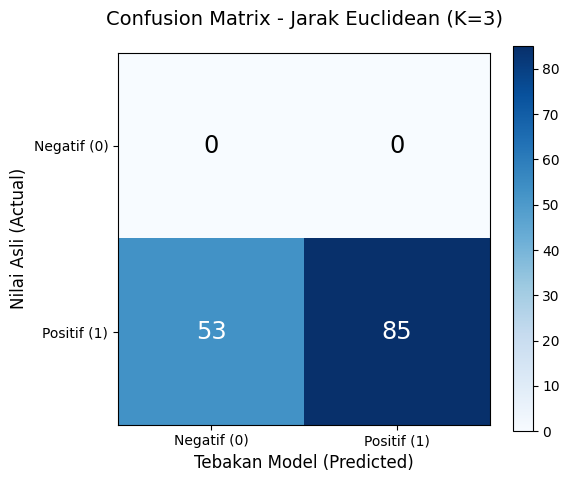

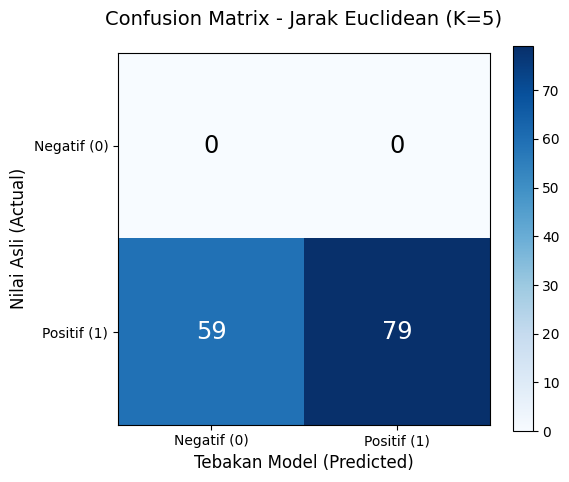

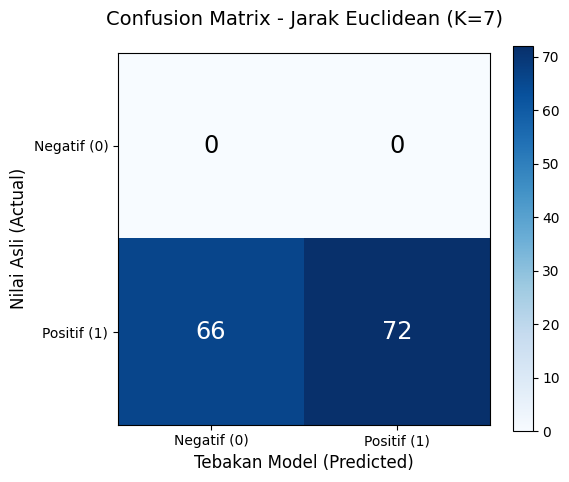

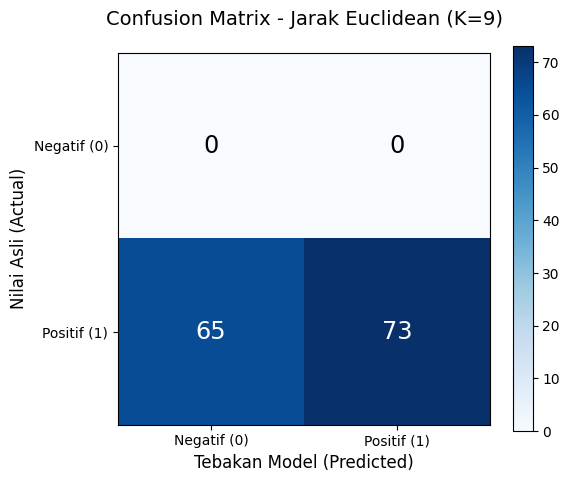

In [69]:
datasetEighty = DatasetEvaluator(readyDf, training_size=0.8)
datasetEighty.split_datasets()
datasetEighty.evaluate_knn()

# 75:25

Dimensi data latih - (516, 5),(516,)
Dimensi data validasi - (172, 5),(172,)
Results for Euclidean Distance (K=3)
Accuracy: 55.23%, Precision: 100.00%, Recall: 55.23%, F1-Score: 71.16%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 45.93%, Precision: 100.00%, Recall: 45.93%, F1-Score: 62.95%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 45.93%, Precision: 100.00%, Recall: 45.93%, F1-Score: 62.95%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 43.60%, Precision: 100.00%, Recall: 43.60%, F1-Score: 60.73%
--------------------------------------------------------------------------------


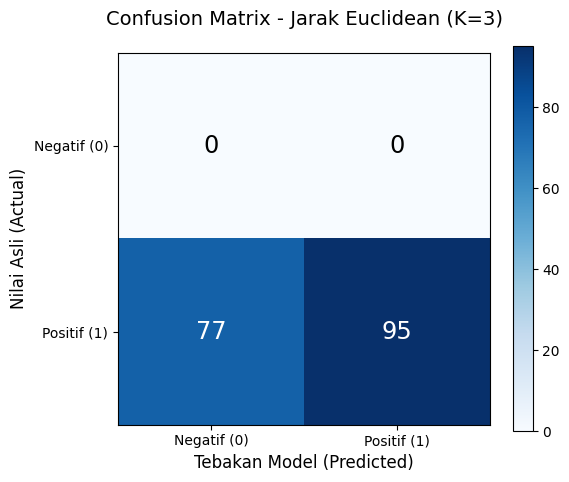

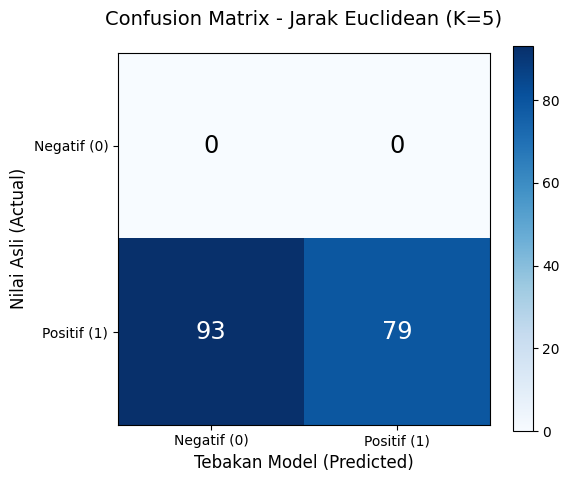

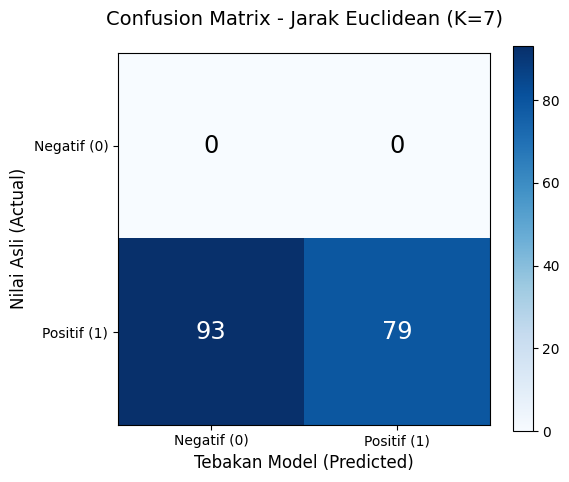

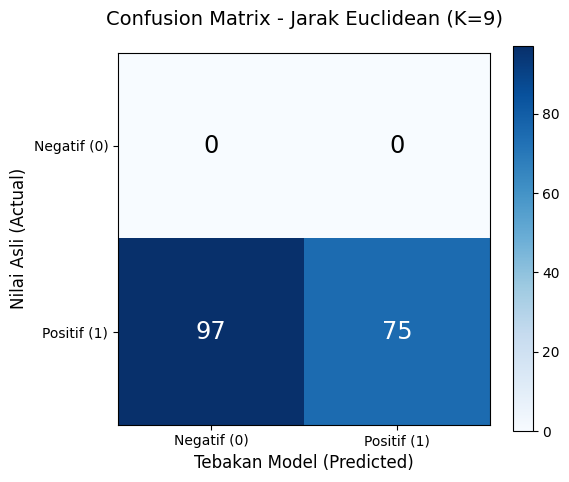

In [70]:
datasetSeventyFive = DatasetEvaluator(readyDf, training_size=0.75)
datasetSeventyFive.split_datasets()
datasetSeventyFive.evaluate_knn()

# 90:10

Dimensi data latih - (619, 5),(619,)
Dimensi data validasi - (69, 5),(69,)
Results for Euclidean Distance (K=3)
Accuracy: 63.77%, Precision: 100.00%, Recall: 63.77%, F1-Score: 77.88%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 56.52%, Precision: 100.00%, Recall: 56.52%, F1-Score: 72.22%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 60.87%, Precision: 100.00%, Recall: 60.87%, F1-Score: 75.68%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 56.52%, Precision: 100.00%, Recall: 56.52%, F1-Score: 72.22%
--------------------------------------------------------------------------------


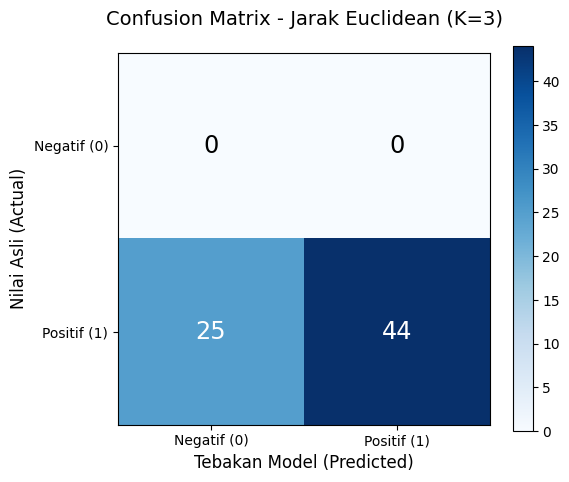

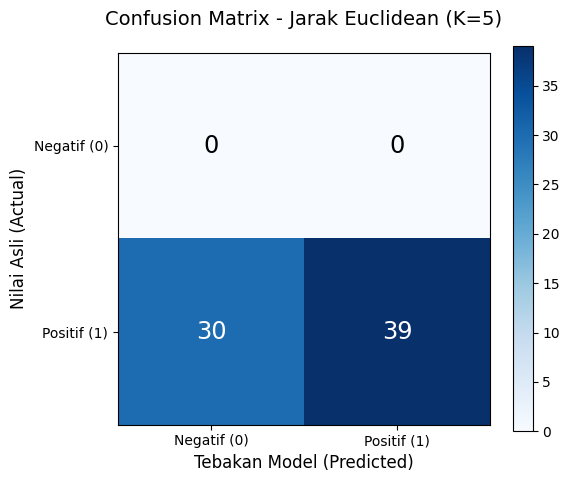

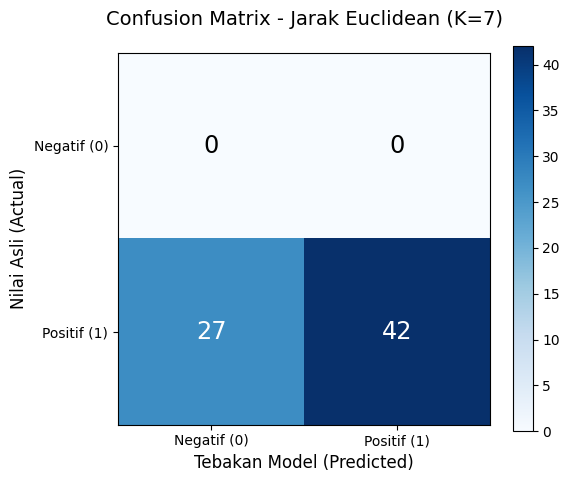

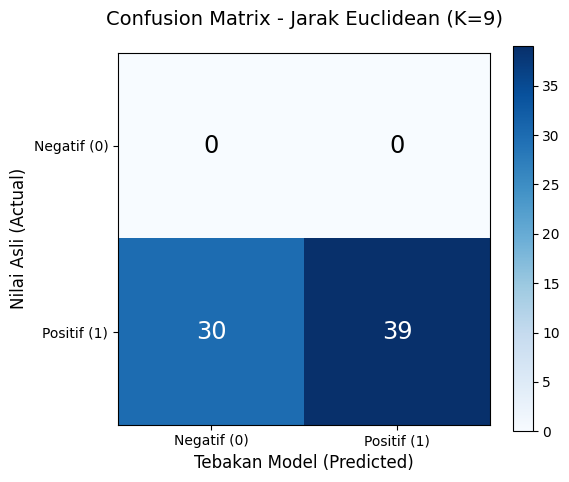

In [71]:
datasetNinety = DatasetEvaluator(readyDf, training_size=0.9)
datasetNinety.split_datasets()
datasetNinety.evaluate_knn()

# K-Fold Cross Validation => K = 4, 5, 10

In [72]:
K = np.array([4, 5, 10])

In [73]:
kFoldDf = pd.read_csv("dataset_preprocessed.csv")[['transformed_gender', 'norm_umur', 'norm_pulse_rate', 'norm_sistolik', 'norm_diastolik', 'norm_glukosa', 'norm_height', 'norm_weight', 'norm_bmi', 'norm_family_diabetes', 'norm_hypertensive', 'norm_family_hypertension', 'norm_cardiovascular_disease', 'norm_stroke', 'diagnosa']]
kFoldDf

,transformed_gender,norm_umur,norm_pulse_rate,norm_sistolik,norm_diastolik,norm_glukosa,norm_height,norm_weight,norm_bmi,norm_family_diabetes,norm_hypertensive,norm_family_hypertension,norm_cardiovascular_disease,norm_stroke,diagnosa
0,0,0.4000,0.541667,0.264,0.500000,0.151422,0.539474,0.304569,0.188837,0.0,0.0,0.0,0.0,0.0,0
1,1,0.6500,0.533333,0.368,0.361111,0.276807,0.342105,0.059222,0.116252,0.0,0.0,0.0,0.0,0.0,0
2,0,0.3625,0.516667,0.208,0.375000,0.240151,0.539474,0.421320,0.266628,0.0,0.0,0.0,0.0,0.0,0
3,0,0.4625,0.550000,0.552,0.611111,0.173004,0.407895,0.177665,0.172932,0.0,0.0,0.0,0.0,0.0,0
4,1,0.5000,0.516667,0.400,0.708333,0.305927,0.434211,0.321489,0.260266,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683,0,0.2125,0.691667,0.200,0.458333,0.383350,0.539474,0.118443,0.064777,0.0,0.0,0.0,0.0,0.0,1
684,0,0.5250,0.516667,0.344,0.458333,0.250428,0.710526,0.734349,0.353383,0.0,0.0,0.0,0.0,0.0,1
685,0,0.4000,0.516667,0.424,0.763889,0.204865,0.605263,0.688663,0.394737,0.0,1.0,0.0,0.0,0.0,1
686,0,0.4625,0.666667,0.256,0.444444,0.238780,0.578947,0.455161,0.268363,0.0,0.0,0.0,0.0,0.0,1


In [74]:
X = kFoldDf[['transformed_gender', 'norm_umur', 'norm_pulse_rate', 'norm_sistolik', 'norm_diastolik', 'norm_glukosa', 'norm_height', 'norm_weight', 'norm_bmi', 'norm_family_diabetes', 'norm_hypertensive', 'norm_family_hypertension', 'norm_cardiovascular_disease', 'norm_stroke']]
y = kFoldDf['diagnosa']

In [75]:
from sklearn.model_selection import StratifiedKFold

results_storage = []

for k_count in K:
    # Buat objek Stratified K-Fold
    skf = StratifiedKFold(n_splits=k_count, shuffle=True, random_state=42)
    
    for fold_index, (train_idx, test_idx) in enumerate(list(skf.split(X,y))):
        k_X_train, k_X_test = X.iloc[train_idx], X.iloc[test_idx]
        k_y_train, k_y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        for k_knn in np.array([3, 5, 7, 9]):
            print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
            knn = KNN(k=k_knn)
            knn.fit(k_X_train, k_y_train)

            predictions = knn.predict(k_X_test.values)
            y_pred = predictions['Euclidean']
            
            evaluator = MetricsEvaluator(y_pred, k_y_test.values)
            
            results_storage.append({
                'K_Fold': k_count,
                'Fold': fold_index + 1,
                'K_KNN': k_knn,
                'Distance': 'Euclidean',
                'Accuracy': evaluator.accuracy(),
                'Precision': evaluator.precision(),
                'Recall': evaluator.recall(),
                'F1_Score': evaluator.f1_score()
            })

Fold 1/4 - K=3
Fold 1/4 - K=5
Fold 1/4 - K=7
Fold 1/4 - K=9
Fold 2/4 - K=3
Fold 2/4 - K=5
Fold 2/4 - K=7
Fold 2/4 - K=9
Fold 3/4 - K=3
Fold 3/4 - K=5
Fold 3/4 - K=7
Fold 3/4 - K=9
Fold 4/4 - K=3
Fold 4/4 - K=5
Fold 4/4 - K=7
Fold 4/4 - K=9
Fold 1/5 - K=3
Fold 1/5 - K=5
Fold 1/5 - K=7
Fold 1/5 - K=9
Fold 2/5 - K=3
Fold 2/5 - K=5
Fold 2/5 - K=7
Fold 2/5 - K=9
Fold 3/5 - K=3
Fold 3/5 - K=5
Fold 3/5 - K=7
Fold 3/5 - K=9
Fold 4/5 - K=3
Fold 4/5 - K=5
Fold 4/5 - K=7
Fold 4/5 - K=9
Fold 5/5 - K=3
Fold 5/5 - K=5
Fold 5/5 - K=7
Fold 5/5 - K=9
Fold 1/10 - K=3
Fold 1/10 - K=5
Fold 1/10 - K=7
Fold 1/10 - K=9
Fold 2/10 - K=3
Fold 2/10 - K=5
Fold 2/10 - K=7
Fold 2/10 - K=9
Fold 3/10 - K=3
Fold 3/10 - K=5
Fold 3/10 - K=7
Fold 3/10 - K=9
Fold 4/10 - K=3
Fold 4/10 - K=5
Fold 4/10 - K=7
Fold 4/10 - K=9
Fold 5/10 - K=3
Fold 5/10 - K=5
Fold 5/10 - K=7
Fold 5/10 - K=9
Fold 6/10 - K=3
Fold 6/10 - K=5
Fold 6/10 - K=7
Fold 6/10 - K=9
Fold 7/10 - K=3
Fold 7/10 - K=5
Fold 7/10 - K=7
Fold 7/10 - K=9
Fold 8/10 - 

In [76]:
df_results = pd.DataFrame(results_storage)
df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,4,1,3,Euclidean,0.750000,0.765432,0.720930,0.742515
1,4,1,5,Euclidean,0.744186,0.762500,0.709302,0.734940
2,4,1,7,Euclidean,0.750000,0.759036,0.732558,0.745562
3,4,1,9,Euclidean,0.773256,0.790123,0.744186,0.766467
4,4,2,3,Euclidean,0.715116,0.717647,0.709302,0.713450
...,...,...,...,...,...,...,...,...
71,10,9,9,Euclidean,0.794118,0.857143,0.705882,0.774194
72,10,10,3,Euclidean,0.779412,0.787879,0.764706,0.776119
73,10,10,5,Euclidean,0.779412,0.851852,0.676471,0.754098
74,10,10,7,Euclidean,0.750000,0.840000,0.617647,0.711864


In [77]:
sorted_df_results = df_results.sort_values(by=['F1_Score'], ascending=False).reset_index(drop=True)
sorted_df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,10,4,9,Euclidean,0.855072,0.852941,0.852941,0.852941
1,10,4,5,Euclidean,0.840580,0.810811,0.882353,0.845070
2,10,4,7,Euclidean,0.826087,0.789474,0.882353,0.833333
3,10,7,9,Euclidean,0.840580,0.900000,0.771429,0.830769
4,10,9,7,Euclidean,0.823529,0.892857,0.735294,0.806452
...,...,...,...,...,...,...,...,...
71,10,3,7,Euclidean,0.739130,0.833333,0.588235,0.689655
72,10,3,5,Euclidean,0.724638,0.777778,0.617647,0.688525
73,10,2,3,Euclidean,0.695652,0.709677,0.647059,0.676923
74,10,5,3,Euclidean,0.666667,0.676471,0.657143,0.666667


In [78]:
best_configs = sorted_df_results.iloc[0:2][['K_Fold', 'Fold', 'K_KNN']]
best_configs

,K_Fold,Fold,K_KNN
0,10,4,9
1,10,4,5


Fold 4/10 - K=9
Fold 4/10 - K=5


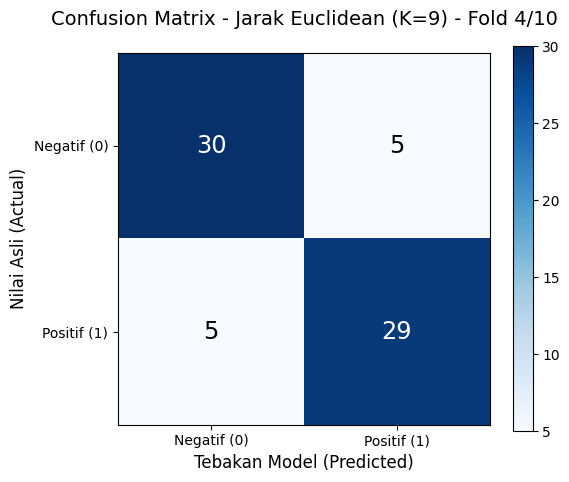

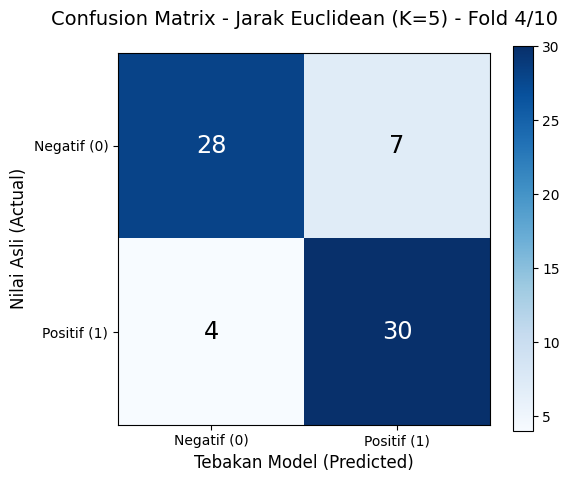

In [79]:
import joblib

skf = StratifiedKFold(n_splits=k_count, shuffle=True, random_state=42)

for best_config in best_configs.itertuples(index=False):
    for k_count in np.array([best_config.K_Fold]): # K-Fold Cross Validation
        for fold_index, (train_idx, test_idx) in enumerate(list(skf.split(X,y))):
            if(fold_index != best_config.Fold - 1): continue # nth Fold, -1 because index starts from 0
            
            best_X_train, best_X_test = X.iloc[train_idx], X.iloc[test_idx]
            best_y_train, best_y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            for k_knn in np.array([best_config.K_KNN]): # K KNN
                print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
                knn = KNN(k=k_knn)
                knn.fit(best_X_train, best_y_train)
                knn.dump(best_X_test, best_y_test)  # Save the test data for later use
                joblib.dump(knn, "best_knn_model.joblib")

                predictions = knn.predict(best_X_test.values)
                best_y_pred = predictions['Euclidean']
                
                evaluator = MetricsEvaluator(best_y_pred, best_y_test.values)
                evaluator.plot_confusion_matrix(
                    title=f"Confusion Matrix - Jarak Euclidean (K={k_knn}) - Fold {fold_index + 1}/{k_count}"
                )

In [80]:
summary_results = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].agg(['mean']).reset_index()
summary_results.columns = ['_'.join(col).strip('_') for col in summary_results.columns.values]
summary_results

,K_Fold,K_KNN,Accuracy_mean,Precision_mean,Recall_mean,F1_Score_mean
0,4,3,0.754360,0.782927,0.709302,0.743444
1,4,5,0.764535,0.797669,0.712209,0.751843
2,4,7,0.774709,0.813518,0.715116,0.760358
3,4,9,0.780523,0.817167,0.723837,0.767277
4,5,3,0.742780,0.767105,0.700554,0.731547
5,5,5,0.761674,0.785211,0.723913,0.752226
6,5,7,0.771818,0.806546,0.721014,0.759663
7,5,9,0.783423,0.819361,0.729710,0.771043
8,10,3,0.736978,0.762793,0.691933,0.722792
9,10,5,0.770375,0.794912,0.732269,0.760090


In [81]:
sorted_kfold = summary_results.sort_values(by='F1_Score_mean', ascending=False)

print(f"K-Fold      : {sorted_kfold.iloc[0]['K_Fold']}")
print(f"K-KNN       : {sorted_kfold.iloc[0]['K_KNN']}")
print(f"Accuracy    : {to_percent(sorted_kfold.iloc[0]['Accuracy_mean'])}")
print(f"Precision   : {to_percent(sorted_kfold.iloc[0]['Precision_mean'])}")
print(f"Recall      : {to_percent(sorted_kfold.iloc[0]['Recall_mean'])}")
print(f"F1-Score    : {to_percent(sorted_kfold.iloc[0]['F1_Score_mean'])}")

K-Fold      : 5.0
K-KNN       : 9.0
Accuracy    : 78.34%
Precision   : 81.94%
Recall      : 72.97%
F1-Score    : 77.10%


In [82]:
# Grouping berdasarkan K_Fold dan K_KNN, lalu hitung rata-rata dari semua fold untuk setiap kombinasi K_Fold dan K_KNN
df_avg_double_k = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean().reset_index()
df_avg_double_k

,K_Fold,K_KNN,Accuracy,Precision,Recall,F1_Score
0,4,3,0.754360,0.782927,0.709302,0.743444
1,4,5,0.764535,0.797669,0.712209,0.751843
2,4,7,0.774709,0.813518,0.715116,0.760358
3,4,9,0.780523,0.817167,0.723837,0.767277
4,5,3,0.742780,0.767105,0.700554,0.731547
5,5,5,0.761674,0.785211,0.723913,0.752226
6,5,7,0.771818,0.806546,0.721014,0.759663
7,5,9,0.783423,0.819361,0.729710,0.771043
8,10,3,0.736978,0.762793,0.691933,0.722792
9,10,5,0.770375,0.794912,0.732269,0.760090
